<a href="https://colab.research.google.com/github/pcmouadji-dot/machine-learning/blob/main/digit_classification(dl_ml).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from sklearn.datasets import load_digits
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import random

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3118 - loss: 2.0984
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5637 - loss: 1.4271
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7843 - loss: 0.8213
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8838 - loss: 0.4861
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9068 - loss: 0.3383
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9290 - loss: 0.2642
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9381 - loss: 0.2293
Epoch 8/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9534 - loss: 0.1766
Epoch 9/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9589 - loss: 0.1537
Epoch 10/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9610 - loss: 0.1430
Epoch 11/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9666 - loss: 0.1264
Epoch 12/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9659 - loss: 0.1132


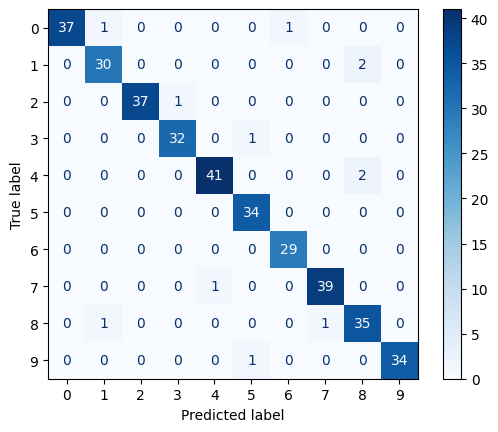

In [ ]:
digits_data=load_digits()
#data=pd.DataFrame(digits_data.data)
x=pd.DataFrame(digits_data.data)
y=digits_data.target
x=x/16
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

# in the tuto he flattenned the data but in this dataset it is already flattened
model=keras.Sequential([
    keras.layers.Dense(64,input_shape=(64,),activation="relu"),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(10,activation="softmax")
])

model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.fit(x_train,y_train,epochs=40)
y_pred=model.predict(x_test)
y_pred=np.argmax(y_pred,axis=1)
cmd=ConfusionMatrixDisplay.from_predictions(y_pred,y_test,cmap="Blues")
plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9667 - loss: 0.1118  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[4]


(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

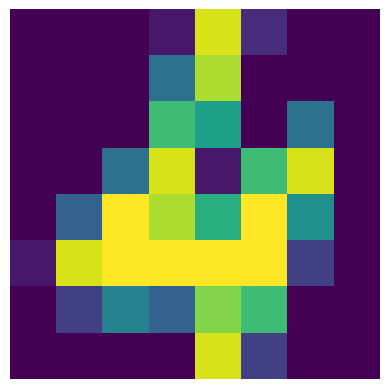

In [ ]:
r=random.randint(0,len(x_test))
model.evaluate(x_test,y_test)
ra=model.predict(x_test.iloc[[r]])
ra=np.argmax(ra,axis=1)
print(ra)
sample=x_test.iloc[r].values
sample=sample.reshape(8,8)
plt.imshow(sample)
plt.axis("off")

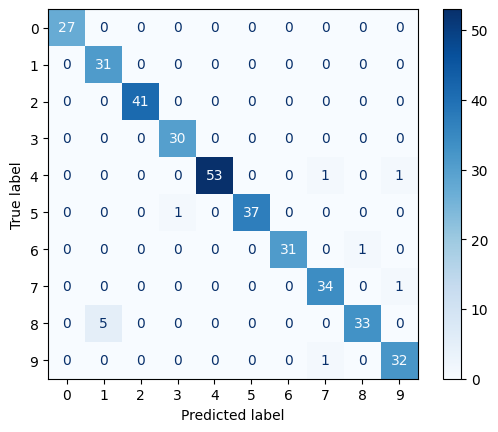

In [ ]:
digits_data = load_digits()
X = pd.DataFrame(digits_data.data)
y = digits_data.target
#sample=data.iloc[5].values
#sample=sample.reshape(8,8)
#plt.imshow(sample,cmap='gray')
#plt.axis("off")
model=RandomForestClassifier()
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2)
model.fit(x_train,y_train)
cmd = ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap='Blues')
plt.show()